# 📊 Impact of TV Advertising on Sales

# Problem Statement
 - Build a model which predicts sales based on the money spent on different platforms for marketing.
 - Use the advertising dataset given in ISLR and analyse the relationship between 'TV advertising' and 'sales' using a simple linear regression model.

# 📈 Workflow Architecture

# 📊 Data Structure

# Importing Libraries

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Dataset Loaded

In [ ]:
df=pd.read_csv(r"advertising.csv")
df

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,12.0
3,151.5,16.5
4,180.8,17.9
...,...,...
195,38.2,7.6
196,94.2,14.0
197,177.0,14.8
198,283.6,25.5


# Data Understanding

In [78]:
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,12.0
3,151.5,16.5
4,180.8,17.9


In [79]:
df.tail()

,TV,Sales
195,38.2,7.6
196,94.2,14.0
197,177.0,14.8
198,283.6,25.5
199,232.1,18.4


In [80]:
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')

Number of Rows: 200
Number of Columns: 2


In [81]:
df.columns

Index(['TV', 'Sales'], dtype='object')

In [82]:
df.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,15.130500
std,85.854236,5.283892
min,0.700000,1.600000
25%,74.375000,11.000000
50%,149.750000,16.000000
75%,218.825000,19.050000
max,296.400000,27.000000


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [84]:
df.dtypes

TV       float64
Sales    float64
dtype: object

# Data Quality Check

In [85]:
df.duplicated().sum()

np.int64(0)

In [86]:
df.isna().sum()

TV       0
Sales    0
dtype: int64

# 📊 Exploratory Data Analysis (EDA)

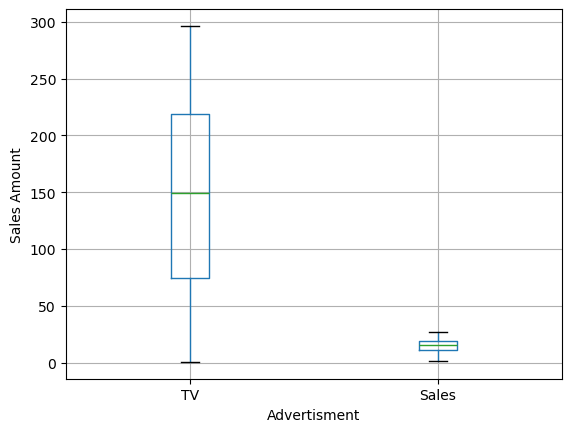

In [17]:
df.boxplot()
plt.xlabel('Advertisment')
plt.ylabel('Sales Amount')
plt.show()

# Univariate Analysis

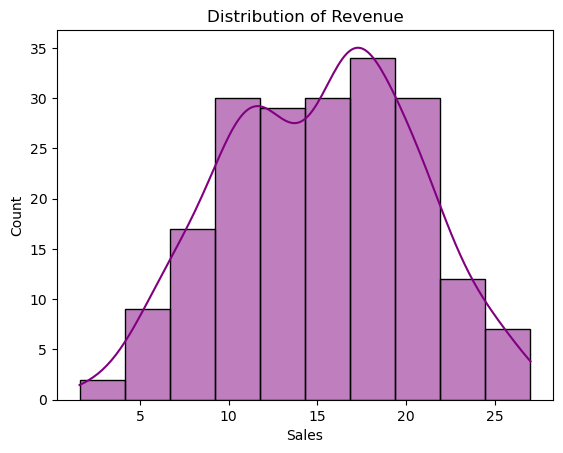

In [88]:
sns.histplot(df['Sales'], kde=True,color='purple')
plt.title('Distribution of Revenue')
plt.show()

# Bivariate Analysis

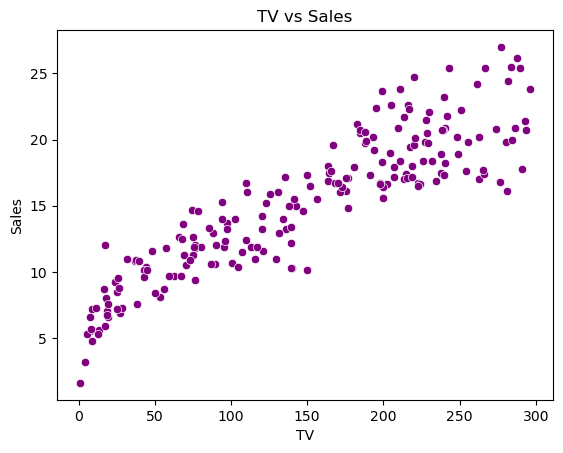

In [67]:
sns.scatterplot(x=df['TV'], y=df['Sales'], color='purple')
plt.title('TV vs Sales')
plt.show()

# Correlation Analysis

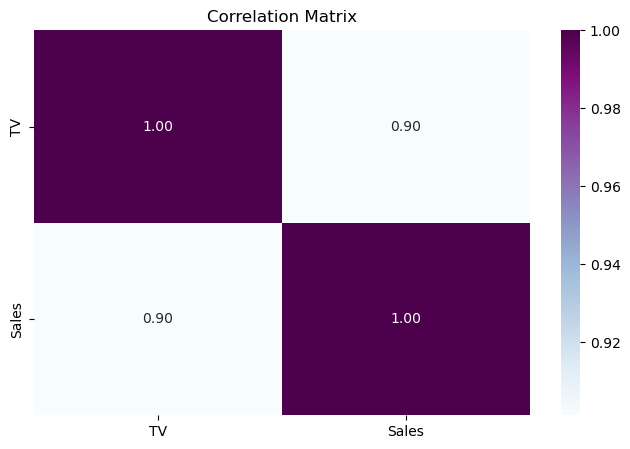

In [89]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='BuPu',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()

# Feature Selection

In [90]:
X=df[['TV']] #independent variables
y=df['Sales'] # dependent variable

# Model Building

In [22]:
lr=LinearRegression()
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [91]:
print(lr.coef_)
print(lr.intercept_)

[0.05546477]
6.9748214882298925


# Prediction

In [30]:
ypred=lr.predict(X)
ypred

array([19.73726517,  9.44300377,  7.92881554, 15.37773421, 17.00285199,
        7.45736499, 10.16404579, 13.6416869 ,  7.45181851, 18.05668263,
       10.64104282, 18.88310771,  8.29488303, 12.38263661, 18.29518114,
       17.81263764, 10.73533293, 22.5826079 , 10.8129836 , 15.14478218,
       19.08832736, 20.142158  ,  7.70695646, 19.63742859, 10.43027669,
       21.55650964, 14.90073719, 20.29191288, 20.77445638, 10.89063428,
       23.22045276, 13.23679407, 12.36599718, 21.70626452, 12.28280002,
       23.09843026, 21.77836873, 11.11803984,  9.3653531 , 19.62078916,
       18.20643751, 16.79208586, 23.2592781 , 18.4504825 ,  8.36698723,
       16.6867028 , 11.9500114 , 20.28081992, 19.57641734, 10.68541463,
       18.05668263, 12.54348444, 18.97739782, 17.10268858, 21.54541669,
       18.00676433,  7.37971431, 14.52912323, 18.6667951 , 18.66124863,
        9.94218671, 21.46776601, 20.24754106, 12.67105342, 14.2462529 ,
       10.80189065,  8.72196176, 14.70106401, 20.142158  , 18.99

# Evaluation metrics

In [92]:
mse=mean_squared_error(y,ypred)
mae=mean_absolute_error(y,ypred)
print(f'Mean_squared_error: {mse}')
print(f'Root_mean_squared_error: {np.sqrt(mse)}')
print(f'Mean_absolute_error: {mae}')
print(f'R2_score: {r2_score(y,ypred)}')

Mean_squared_error: 5.2177438977951285
Root_mean_squared_error: 2.2842381438447106
Mean_absolute_error: 1.8305872641932417
R2_score: 0.8121757029987414


# Visualization of Results

In [93]:
df['Predicted Sales']=ypred

In [94]:
df.head()

,TV,Sales,Predicted Sales
0,230.1,22.1,19.737265
1,44.5,10.4,9.443004
2,17.2,12.0,7.928816
3,151.5,16.5,15.377734
4,180.8,17.9,17.002852


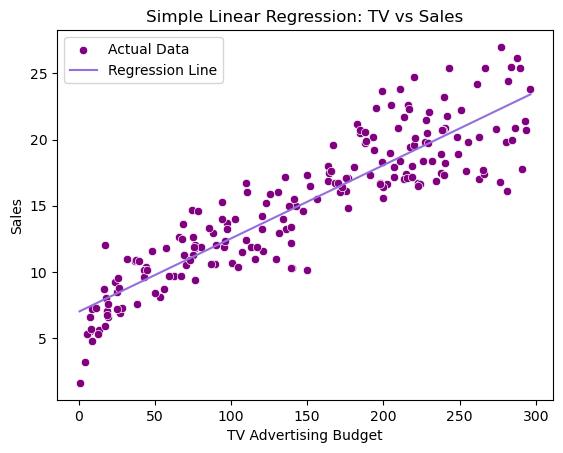

In [95]:
sns.scatterplot(x=df['TV'], y=df['Sales'], color='purple', label='Actual Data')
sns.lineplot(x=df['TV'], y=ypred, color='mediumpurple', label='Regression Line')

plt.title('Simple Linear Regression: TV vs Sales')
plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')
plt.legend()
plt.show()

# Final Model

In [96]:
print("╔══════════════════════════════════════════════╗")
print("║       FINAL MODEL PERFORMANCE SUMMARY        ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  R² Score              : {r2_score(y, ypred)*100:>7.2f}%            ║")
print(f"║  MAE                   : {mae:>10.2f}          ║")
print(f"║  RMSE                  : {np.sqrt(mse):>10.2f}          ║")
print(f"║  Features Used         : {X.shape[1]:>10}          ║")
print("╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║       FINAL MODEL PERFORMANCE SUMMARY        ║
╠══════════════════════════════════════════════╣
║  R² Score              :   81.22%            ║
║  MAE                   :       1.83          ║
║  RMSE                  :       2.28          ║
║  Features Used         :          1          ║
╚══════════════════════════════════════════════╝


# Conclusion
- The Simple Linear Regression model shows a good performance in predicting Sales based on TV advertising spend.
- The R² score of 0.81 indicates that approximately 81% of the variation in Sales is explained by TV advertising, which suggests a strong positive relationship between advertising spend and sales revenue.
 - The low MAE (1.83) and RMSE (2.28) indicate that the model’s prediction errors are relatively small and acceptable.
 - Overall, the model is able to capture the trend effectively, though there is still a small amount of unexplained variation that could be improved with additional features or more complex models